# **Life Expectancy Analysis EDA & Machine Learning**

| | |
|---|---|
| **Author** | Ibrahim A. Mikail |
| **Internship** | Unified Mentor — Healthcare Data Analyst |
| **Project** | 3 of 5 |
| **Tools** | Python · Pandas · SQLite · Matplotlib · Seaborn · Scikit-learn |
| **Dataset** | WHO & United Nations via Kaggle |
| **Date** | May 2026 |

---

## **Project Overview**
This dataset contains health, economic and social indicators for 193 countries spanning 2000-2015, collected from the WHO Global Health Observatory and the United Nations. The project performs exploratory data analysis and builds machine learning regression models to identify the key factors that predict life expectancy and quantify their impact.

## **Key Questions**
1. Which factors most significantly affect life expectancy?
2. Should countries with low life expectancy increase healthcare expenditure?
3. How do infant and adult mortality rates affect life expectancy?
4. What is the impact of schooling, immunization and economic factors on lifespan?
5. Can we build a reliable model to predict life expectancy from these factors?

In [1]:
# ──Project Setup ──────────────────────────────────────────────────────
import os
from pathlib import Path

ROOT    = Path().resolve()
DATA    = ROOT / "data"
OUTPUTS = ROOT / "outputs"
DB_PATH = ROOT / "life_expectancy.db"

for folder in [DATA, OUTPUTS]:
    folder.mkdir(parents=True, exist_ok=True)
    print(f" {folder}")

print(f"\nProject root : {ROOT}")
print(f"Database will be created at : {DB_PATH}")

 C:\Users\DELL\Documents\Data Science Projects\unified_mentor_projects\project_3_life_expectancy\data
 C:\Users\DELL\Documents\Data Science Projects\unified_mentor_projects\project_3_life_expectancy\outputs

Project root : C:\Users\DELL\Documents\Data Science Projects\unified_mentor_projects\project_3_life_expectancy
Database will be created at : C:\Users\DELL\Documents\Data Science Projects\unified_mentor_projects\project_3_life_expectancy\life_expectancy.db


In [2]:
# ──Imports & Global Settings ─────────────────────────────────────────
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

# Display settings
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.2f}".format)

# Chart style
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("Blues_r")

import warnings
warnings.filterwarnings("ignore")


---
### **Loading Data & Ingesting to SQLite**

In [3]:
# ──Loading CSV & Pushing to SQLite ─────────────────────────────────────────
df_raw = pd.read_csv(DATA / "Life Expectancy Data.csv")

# Connecting to SQLite
conn = sqlite3.connect(DB_PATH)

# Pushing to SQLite
df_raw.to_sql("life_expectancy", conn, if_exists="replace", index=False)

print(f" CSV loaded           : {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")
print(f" SQLite table created : 'life_expectancy'")
print(f" Database saved at    : {DB_PATH}")

 CSV loaded           : 2,938 rows, 22 columns
 SQLite table created : 'life_expectancy'
 Database saved at    : C:\Users\DELL\Documents\Data Science Projects\unified_mentor_projects\project_3_life_expectancy\life_expectancy.db


In [4]:
# ── Initial inspection ────────────────────────────────────────────────────────
df = pd.read_sql("SELECT * FROM life_expectancy LIMIT 5", conn)
df

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.00,263.00,62,0.01,71.28,65.00,1154,19.10,83,6.00,8.16,65.00,0.10,584.26,33736494.00,17.20,17.30,0.48,10.10
1,Afghanistan,2014,Developing,59.90,271.00,64,0.01,73.52,62.00,492,18.60,86,58.00,8.18,62.00,0.10,612.70,327582.00,17.50,17.50,0.48,10.00
2,Afghanistan,2013,Developing,59.90,268.00,66,0.01,73.22,64.00,430,18.10,89,62.00,8.13,64.00,0.10,631.74,31731688.00,17.70,17.70,0.47,9.90
3,Afghanistan,2012,Developing,59.50,272.00,69,0.01,78.18,67.00,2787,17.60,93,67.00,8.52,67.00,0.10,669.96,3696958.00,17.90,18.00,0.46,9.80
4,Afghanistan,2011,Developing,59.20,275.00,71,0.01,7.10,68.00,3013,17.20,97,68.00,7.87,68.00,0.10,63.54,2978599.00,18.20,18.20,0.45,9.50


In [5]:
# ── Shape, Columns & Data Types ───────────────────────────────────────
print(f"Shape: {df_raw.shape}")
print(f"\nColumns:\n{df_raw.columns.tolist()}")
print(f"\nData Types:\n{df_raw.dtypes}")

Shape: (2938, 22)

Columns:
['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years', ' thinness 5-9 years', 'Income composition of resources', 'Schooling']

Data Types:
Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
D

---
### **Missing Data Analysis**

In [6]:
# ──Missing Data Percentage ───────────────────────────────────────────
missing = pd.DataFrame({
    "Missing Count" : df_raw.isnull().sum(),
    "Missing %"     : (df_raw.isnull().mean() * 100).round(2)
}).sort_values("Missing %", ascending=False)

missing[missing["Missing %"] > 0]

,Missing Count,Missing %
Population,652,22.19
Hepatitis B,553,18.82
GDP,448,15.25
Total expenditure,226,7.69
Alcohol,194,6.60
Income composition of resources,167,5.68
Schooling,163,5.55
thinness 5-9 years,34,1.16
thinness 1-19 years,34,1.16
BMI,34,1.16


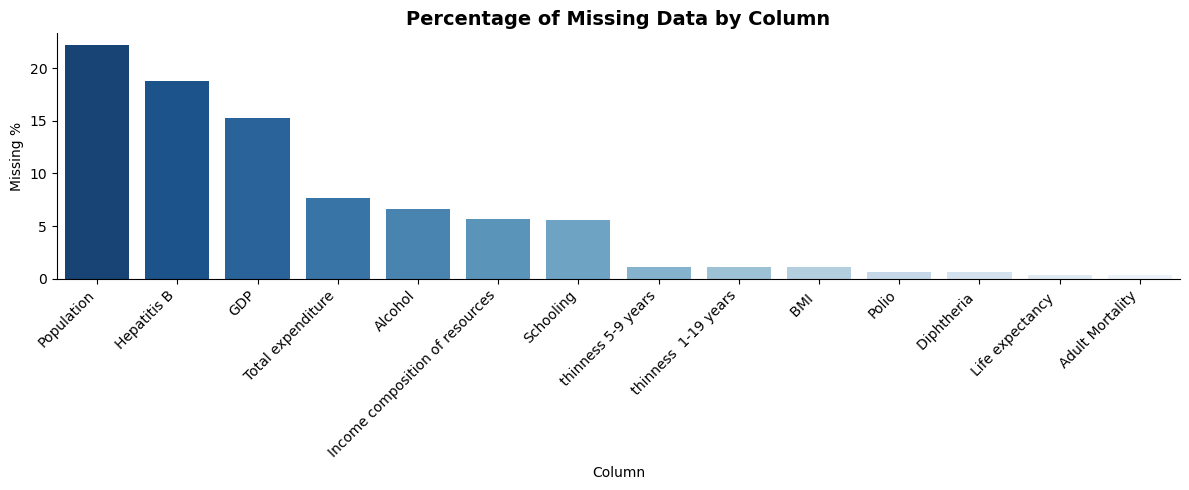

In [7]:
# ──Visualising Missing Data ────────────────────────────────────────────
missing_plot = missing[missing["Missing %"] > 0]

plt.figure(figsize=(12, 5))
sns.barplot(x=missing_plot.index, y=missing_plot["Missing %"], palette="Blues_r")
plt.title("Percentage of Missing Data by Column", fontsize=14, fontweight="bold")
plt.xlabel("Column")
plt.ylabel("Missing %")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUTS / "missing_data.png", dpi=150)
plt.show()

### Missing Data Observations
- **Population (22%)** MAR: missingness concentrated in less developed/smaller nations with limited data infrastructure. Will impute with country-level median
- **Hepatitis B (19%)** MAR: confirmed by dataset brief as missing from less known countries. Will impute with country-level median
- **GDP (15%)** MAR: same as above, economic data unavailable for smaller nations. Will impute with country-level median
- **Schooling, Alcohol, Total expenditure, Income composition (5-8%)** MAR: country-level panel data. Will impute using grouped median by Country to maintain the time-series structure of the data
- **BMI, thinness, Polio, Diphtheria (<2%)** MCAR: low random missingness, will impute with country-level median
- **Life expectancy & Adult Mortality (0.34%)** is the target variable. Rows with missing values will be dropped entirely as we cannot impute what we are trying to predict

---
### **Data Cleaning & Feature Engineering**

#### **Cleaning Column Names**

In [8]:
# ──Cleaning Column Names ─────────────────────────────────────────────────
# Strip leading/trailing whitespace from all column names
df_clean = df_raw.copy()
df_clean.columns = df_clean.columns.str.strip()

# Also cleaning up double spaces inside column names
df_clean.columns = df_clean.columns.str.replace(r'\s+', ' ', regex=True)

print("Cleaned column names:")
print(df_clean.columns.tolist())

Cleaned column names:
['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness 1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


In [9]:
# ──Handle Missing Values ─────────────────────────────────────────────
# Drop rows where target variable is missing
before = df_clean.shape[0]
df_clean.dropna(subset=["Life expectancy", "Adult Mortality"], inplace=True)
after = df_clean.shape[0]
print(f" Dropped {before - after} rows with missing target variable")

# Country-grouped median imputation for panel data columns
group_cols = ["Schooling", "Alcohol", "Total expenditure", 
              "Income composition of resources", "Hepatitis B",
              "GDP", "Population", "BMI", "thinness 1-19 years",
              "thinness 5-9 years", "Polio", "Diphtheria"]

for col in group_cols:
    before_nulls = df_clean[col].isnull().sum()
    df_clean[col] = df_clean.groupby("Country")[col].transform(
        lambda x: x.fillna(x.median())
    )
    # If still null (country had all nulls), fill with global median
    remaining = df_clean[col].isnull().sum()
    if remaining > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)
    print(f" {col:<35} {before_nulls} nulls imputed")

print(f"\n Remaining nulls : {df_clean.isnull().sum().sum()}")
print(f" Final shape     : {df_clean.shape}")

 Dropped 10 rows with missing target variable
 Schooling                           160 nulls imputed
 Alcohol                             193 nulls imputed
 Total expenditure                   226 nulls imputed
 Income composition of resources     160 nulls imputed
 Hepatitis B                         553 nulls imputed
 GDP                                 443 nulls imputed
 Population                          644 nulls imputed
 BMI                                 32 nulls imputed
 thinness 1-19 years                 32 nulls imputed
 thinness 5-9 years                  32 nulls imputed
 Polio                               19 nulls imputed
 Diphtheria                          19 nulls imputed

 Remaining nulls : 0
 Final shape     : (2928, 22)


In [10]:
# ──Feature Engineering ──────────────────────────────────────────────
# Encode Status (Developing/Developed) as binary
df_clean["Status_encoded"] = (df_clean["Status"] == "Developed").astype(int)

# Mortality rate ratio (combined mortality pressure)
df_clean["mortality_ratio"] = df_clean["Adult Mortality"] / (df_clean["infant deaths"] + 1)

# Immunization coverage average across 3 vaccines
df_clean["immunization_avg"] = df_clean[["Hepatitis B", "Polio", "Diphtheria"]].mean(axis=1)

print(" Status encoded as binary (1=Developed, 0=Developing)")
print(" Mortality ratio engineered")
print(" Immunization average engineered")
print(f" Final shape : {df_clean.shape}")

 Status encoded as binary (1=Developed, 0=Developing)
 Mortality ratio engineered
 Immunization average engineered
 Final shape : (2928, 25)


In [11]:
# ──Saving Cleaned Data ─────────────────────────────────────────────────
df_clean.to_sql("life_expectancy_clean", conn, if_exists="replace", index=False)
df_clean.to_csv(OUTPUTS / "life_expectancy_cleaned.csv", index=False)

print(f" Final dataset : {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns")

 Final dataset : 2,928 rows, 25 columns


### 4.1 Cleaning Observations
- Column names stripped of leading/trailing whitespace and double spaces to prevent KeyError issues during analysis
- 10 rows dropped where target variable (Life expectancy) was missing as we cannot impute what we are predicting
- Country-grouped median imputation applied to all numeric columns. It respects the panel data structure by using each country's own historical data as the imputation reference rather than a global median
- Global median used as fallback for countries with all nulls in a column
- 3 new features engineered:
    - `Status_encoded` : binary encoding of Developed/Developing status
    - `mortality_ratio` : combined adult and infant mortality pressure
    - `immunization_avg` : average coverage across Hepatitis B, Polio and Diphtheria
- Final dataset: 2,928 rows, 25 columns ready for analysis

---
### **Exploratory Data Analysis**

#### **Life Expectancy Distribution**
How is life expectancy distributed globally?

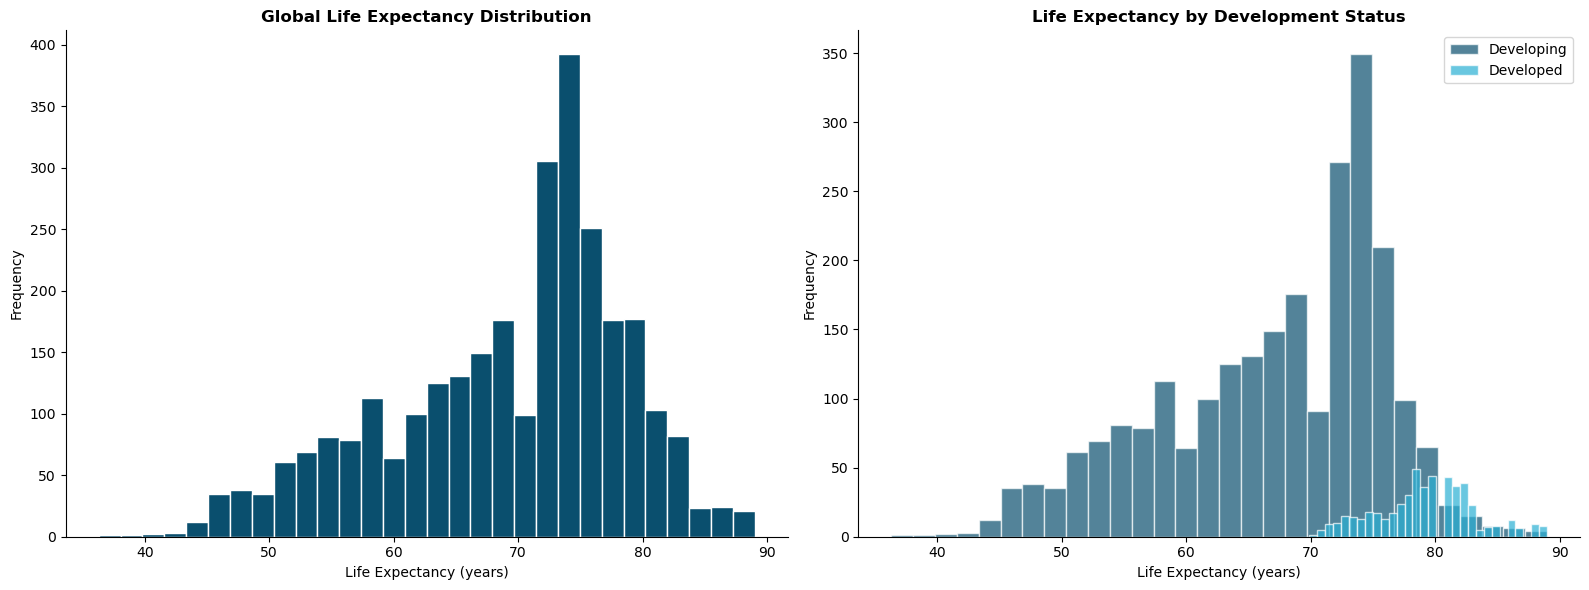

Global Mean    : 69.2 years
Developed Mean : 79.2 years
Developing Mean: 67.1 years
Gap            : 12.1 years


In [12]:
# ──Life Expectancy Distribution ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall distribution
axes[0].hist(df_clean["Life expectancy"], bins=30, 
             color="#0a4f6e", edgecolor="white")
axes[0].set_title("Global Life Expectancy Distribution", fontweight="bold")
axes[0].set_xlabel("Life Expectancy (years)")
axes[0].set_ylabel("Frequency")

# By development status
developed   = df_clean[df_clean["Status"] == "Developed"]["Life expectancy"]
developing  = df_clean[df_clean["Status"] == "Developing"]["Life expectancy"]

axes[1].hist(developing, bins=30, alpha=0.7, color="#0a4f6e", 
             label="Developing", edgecolor="white")
axes[1].hist(developed, bins=30, alpha=0.7, color="#2ab0d4", 
             label="Developed", edgecolor="white")
axes[1].set_title("Life Expectancy by Development Status", fontweight="bold")
axes[1].set_xlabel("Life Expectancy (years)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUTS / "life_expectancy_dist.png", dpi=150)
plt.show()

print(f"Global Mean    : {df_clean['Life expectancy'].mean():.1f} years")
print(f"Developed Mean : {developed.mean():.1f} years")
print(f"Developing Mean: {developing.mean():.1f} years")
print(f"Gap            : {developed.mean() - developing.mean():.1f} years")

#### Observations
- Global mean life expectancy is 69.2 years across 193 countries from 2000-2015
- A striking 12.1 year gap exists between developed (79.2 years) and developing countries (67.1 years) a child's birthplace alone accounts for over a decade difference in expected lifespan
- The global distribution is bimodal. One peak around 65-70 years (developing nations) and another around 75-80 years (developed nations), confirming the two-speed nature of global health outcomes
- Developed country distribution is tightly clustered at the high end, while developing countries show much wider spread. This reflects greater inequality within the developing world

#### **Life Expectancy Trends Over Time (2000-2015)**
How has life expectancy evolved globally over the 15-year period?

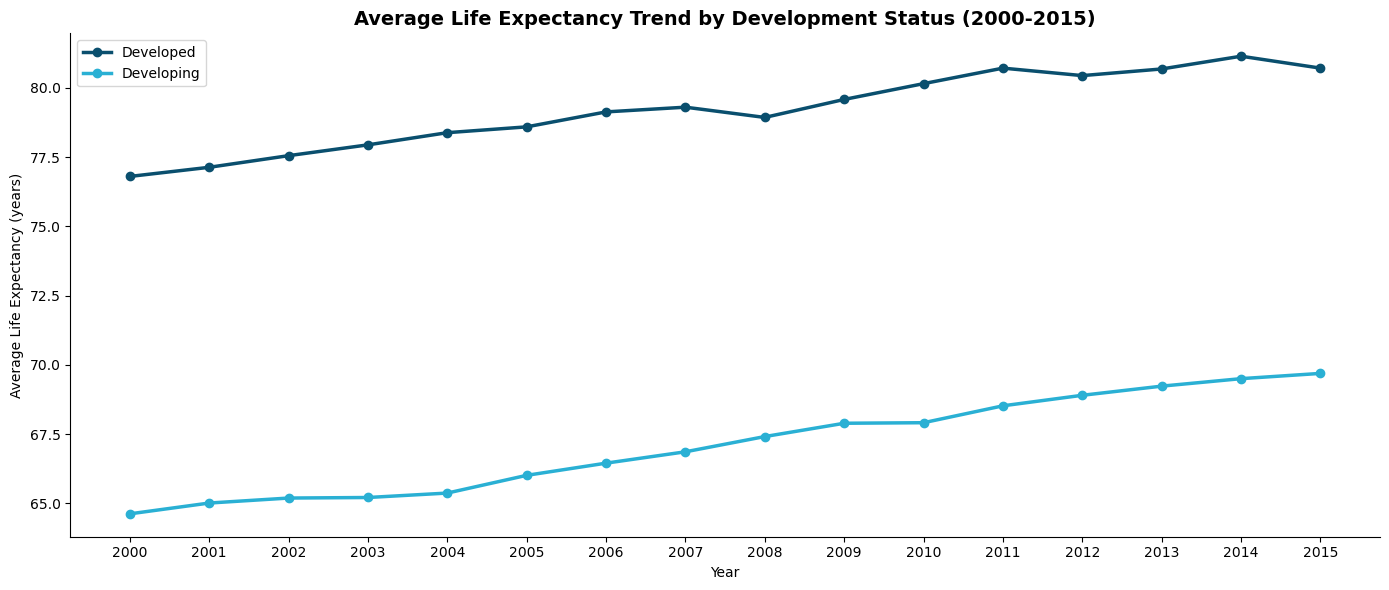

In [13]:
# ──Trends Over Time ──────────────────────────────────────────────────
trend_df = pd.read_sql("""
    SELECT Year, Status,
           ROUND(AVG("Life expectancy"), 2) as Avg_Life_Expectancy
    FROM life_expectancy_clean
    GROUP BY Year, Status
    ORDER BY Year
""", conn)

plt.figure(figsize=(14, 6))
for status, group in trend_df.groupby("Status"):
    plt.plot(group["Year"], group["Avg_Life_Expectancy"],
             marker="o", linewidth=2.5,
             label=status,
             color="#0a4f6e" if status == "Developed" else "#2ab0d4")

plt.title("Average Life Expectancy Trend by Development Status (2000-2015)",
          fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Average Life Expectancy (years)")
plt.legend()
plt.xticks(range(2000, 2016))
plt.tight_layout()
plt.savefig(OUTPUTS / "life_expectancy_trend.png", dpi=150)
plt.show()

#### Observations
- Both developed and developing countries show consistent improvement in life expectancy from 2000-2015, reflecting global progress in healthcare, immunization and disease control
- Developing countries improved from 64.7 to 69.8 years. This is a gain of ~5 years over 15 years, suggesting accelerating healthcare development in lower-income nations
- Developed countries improved from 77.0 to 80.8 years which is a smaller absolute gain reflecting already high baseline levels
- A notable dip appears for developed countries around 2008 that is consistent with the global financial crisis, which reduced healthcare spending, increased unemployment and negatively impacted population health outcomes
- Despite both groups improving, the gap remains persistently wide. Convergence is occurring but slowly

#### **Correlation Analysis**
Which factors are most strongly correlated with life expectancy?

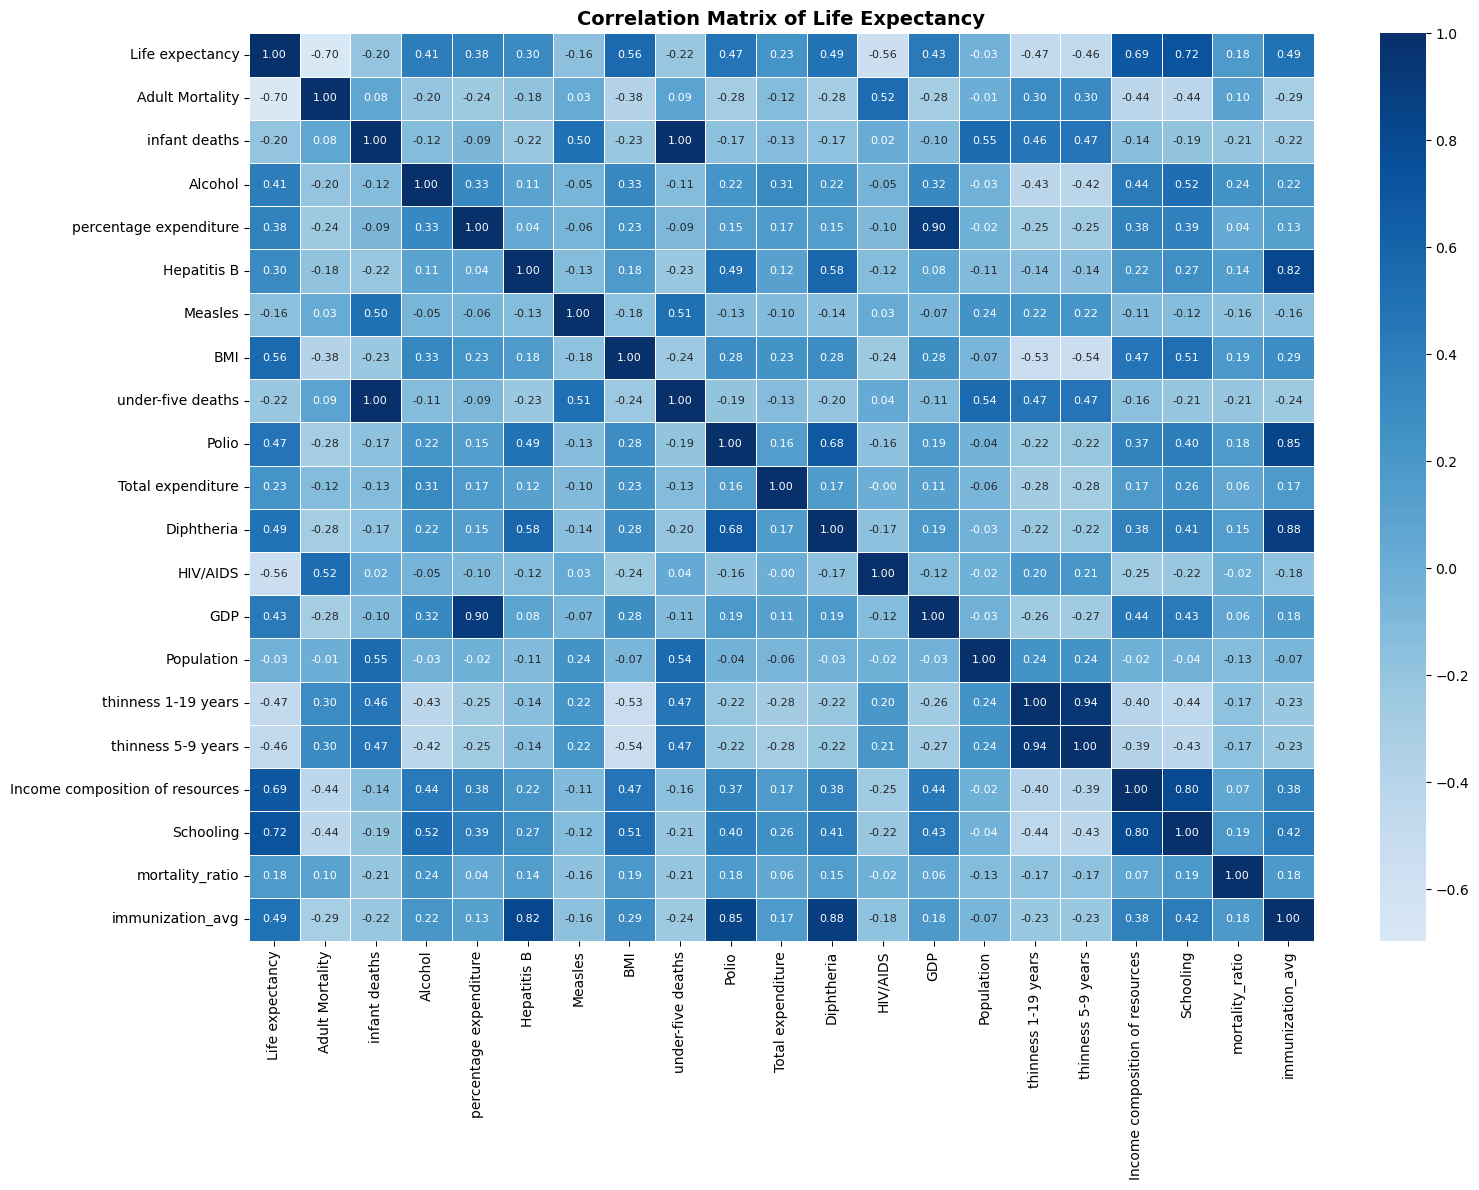

In [14]:
# ──Correlation Matrix ────────────────────────────────────────────────
# Select numeric columns only
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ["Year", "Status_encoded"]]

corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="Blues",
            center=0, linewidths=0.5, annot_kws={"size": 8})
plt.title("Correlation Matrix of Life Expectancy",
          fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS / "correlation_matrix.png", dpi=150)
plt.show()

#### Observations
- **Schooling (0.72)** is the strongest positive predictor of life expectancy surpassing even GDP and healthcare expenditure. Education drives health literacy, earlier disease detection, better nutrition decisions and higher vaccination rates
- **Income composition of resources (0.69)** reflects how efficiently a country converts income into human development. This is a strong proxy for institutional quality
- **BMI (0.56)** is counterintuitively positive in this global context in developing nations low BMI signals malnutrition and poverty, so higher BMI reflects better nutrition and food security
- **Adult Mortality (-0.70)** is the strongest negative predictor. As expected, higher death rates among adults directly compress life expectancy
- **HIV/AIDS (-0.56)** has a strong negative impact particularly relevant for Sub-Saharan African countries where the epidemic significantly reduced life expectancy
- **Thinness (-0.47)** confirms that malnutrition is a major life expectancy driver in developing nations
- These correlations will directly inform our feature selection for the ML models

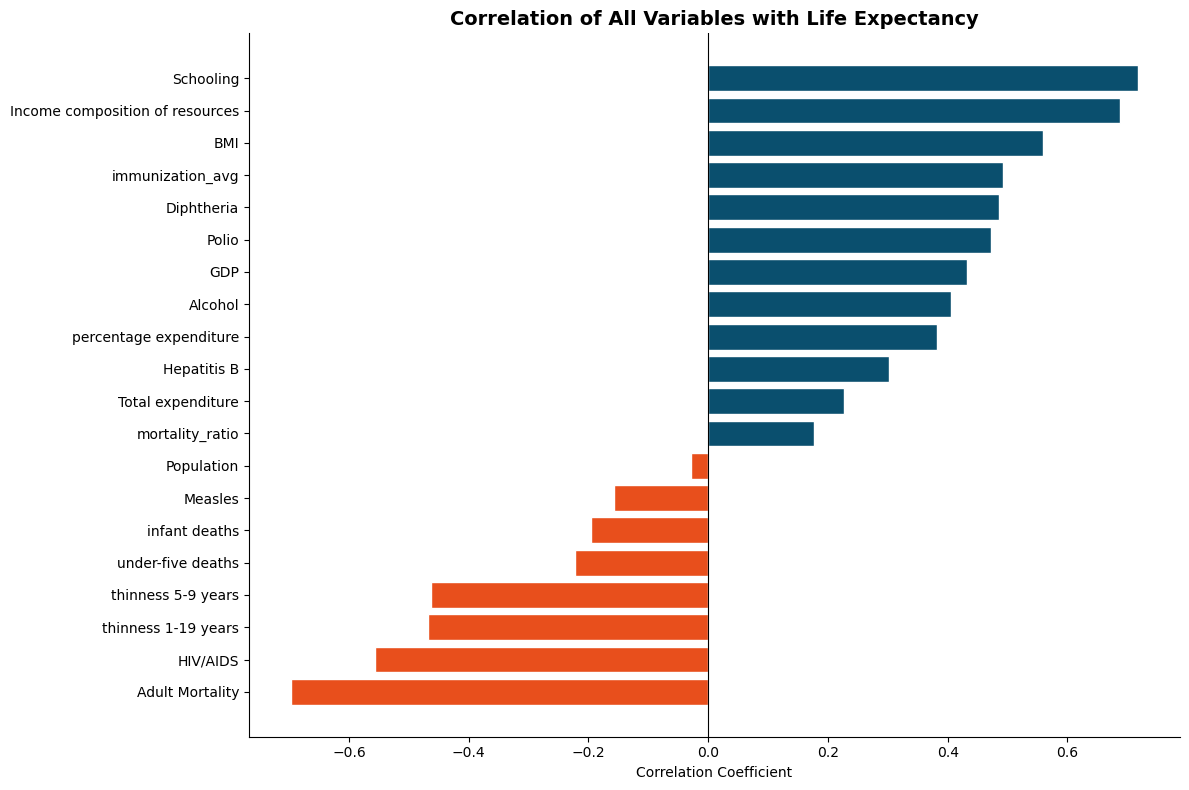

In [15]:
# ──Top Correlations with Life Expectancy ────────────────────────────
le_corr = corr_matrix["Life expectancy"].drop("Life expectancy").sort_values()

plt.figure(figsize=(12, 8))
colors = ["#e84f1c" if x < 0 else "#0a4f6e" for x in le_corr.values]
plt.barh(le_corr.index, le_corr.values, color=colors, edgecolor="white")
plt.title("Correlation of All Variables with Life Expectancy",
          fontsize=14, fontweight="bold")
plt.xlabel("Correlation Coefficient")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig(OUTPUTS / "correlations_life_expectancy.png", dpi=150)
plt.show()

---
### **Predicting Life Expectancy (Machine Learning)**

#### **Feature Selection & Data Preparation**
Selecting features based on correlation analysis and preparing data for modelling.

In [16]:
# ── Feature Selection & Train/Test Split ──────────────────────────────
# Features selected after removing multicollinear variables:
# - immunization_avg replaces Hepatitis B, Polio, Diphtheria
# - infant deaths replaces under-five deaths (correlation = 1.00)
# - thinness 1-19 years replaces thinness 5-9 years (correlation = 0.94)

features = [
    "Adult Mortality",
    "Schooling",
    "Income composition of resources",
    "BMI",
    "HIV/AIDS",
    "GDP",
    "Alcohol",
    "percentage expenditure",
    "Total expenditure",
    "thinness 1-19 years",
    "immunization_avg",
    "Status_encoded",
    "infant deaths",
    "Population"
]

target = "Life expectancy"

X = df_clean[features]
y = df_clean[target]

# Train/test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f" Features selected  : {len(features)}")
print(f" Multicollinear features removed : Hepatitis B, Polio, Diphtheria,")
print(f"  under-five deaths, thinness 5-9 years")
print(f" Features selected  : {len(features)}")
print(f" Training samples   : {X_train.shape[0]:,}")
print(f" Testing samples    : {X_test.shape[0]:,}")

 Features selected  : 14
 Multicollinear features removed : Hepatitis B, Polio, Diphtheria,
  under-five deaths, thinness 5-9 years
 Features selected  : 14
 Training samples   : 2,342
 Testing samples    : 586


── Linear Regression Results ─────────────────────
R² Score : 0.8078
RMSE     : 4.0773 years


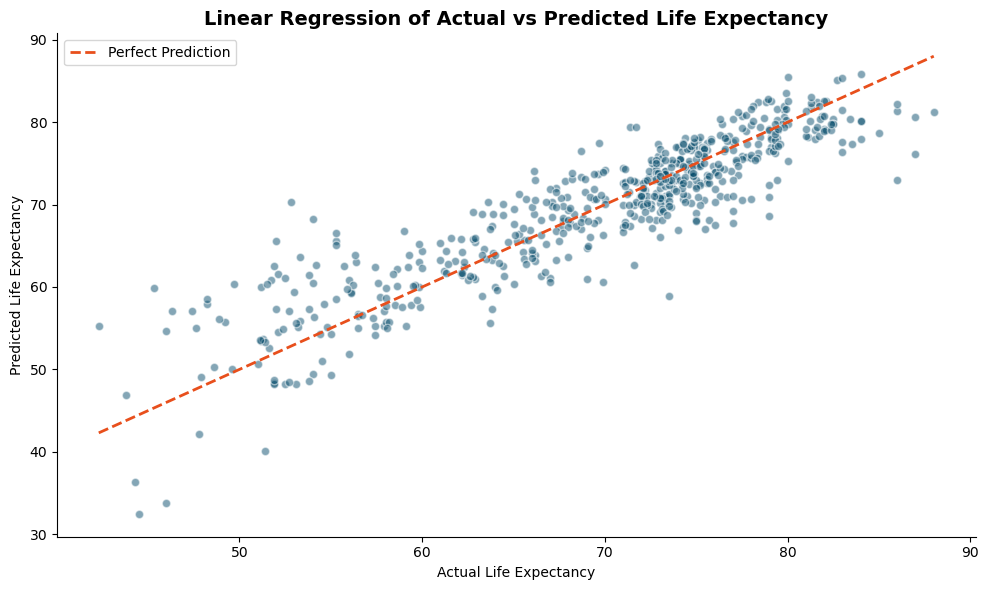

In [17]:
# ──Linear Regression Model ──────────────────────────────────────────
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
lr_pred = lr_model.predict(X_test)

# Evaluation
lr_r2   = r2_score(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

print("── Linear Regression Results ─────────────────────")
print(f"R² Score : {lr_r2:.4f}")
print(f"RMSE     : {lr_rmse:.4f} years")

# Visualise actual vs predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, lr_pred, alpha=0.5, color="#0a4f6e", edgecolor="white")
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         color="#e84f1c", linewidth=2, linestyle="--", label="Perfect Prediction")
plt.title("Linear Regression of Actual vs Predicted Life Expectancy",
          fontsize=14, fontweight="bold")
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUTS / "lr_actual_vs_predicted.png", dpi=150)
plt.show()

── Random Forest Results ──────────────────────────
R² Score : 0.9660
RMSE     : 1.7148 years


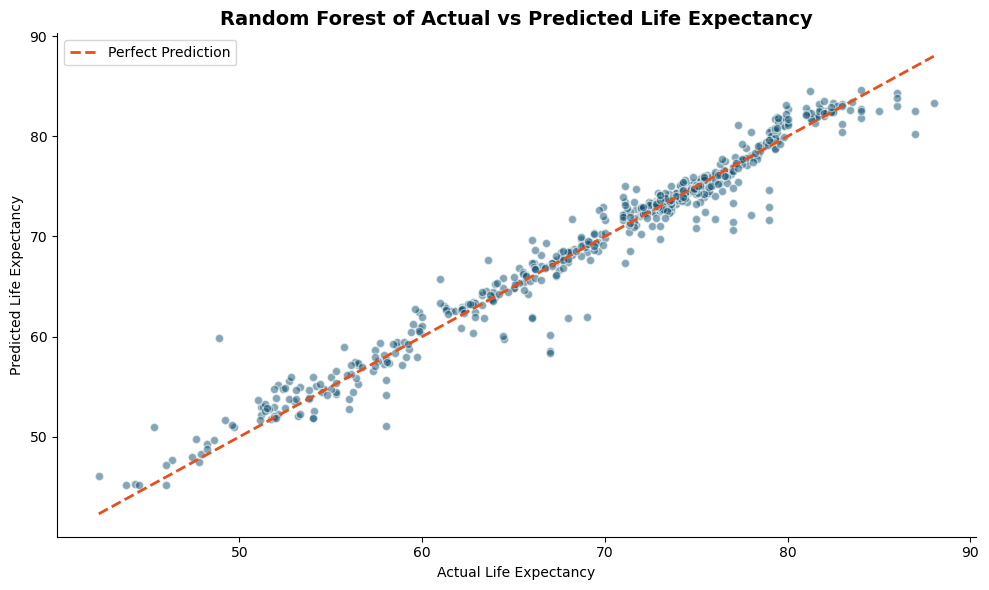

In [18]:
# ──Random Forest Model ──────────────────────────────────────────────
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Evaluation
rf_r2   = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("── Random Forest Results ──────────────────────────")
print(f"R² Score : {rf_r2:.4f}")
print(f"RMSE     : {rf_rmse:.4f} years")

# Visualise actual vs predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, rf_pred, alpha=0.5, color="#0a4f6e", edgecolor="white")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="#e84f1c", linewidth=2, linestyle="--", label="Perfect Prediction")
plt.title("Random Forest of Actual vs Predicted Life Expectancy",
          fontsize=14, fontweight="bold")
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUTS / "rf_actual_vs_predicted.png", dpi=150)
plt.show()

            Model  R² Score  RMSE
Linear Regression      0.81  4.08
    Random Forest      0.97  1.71


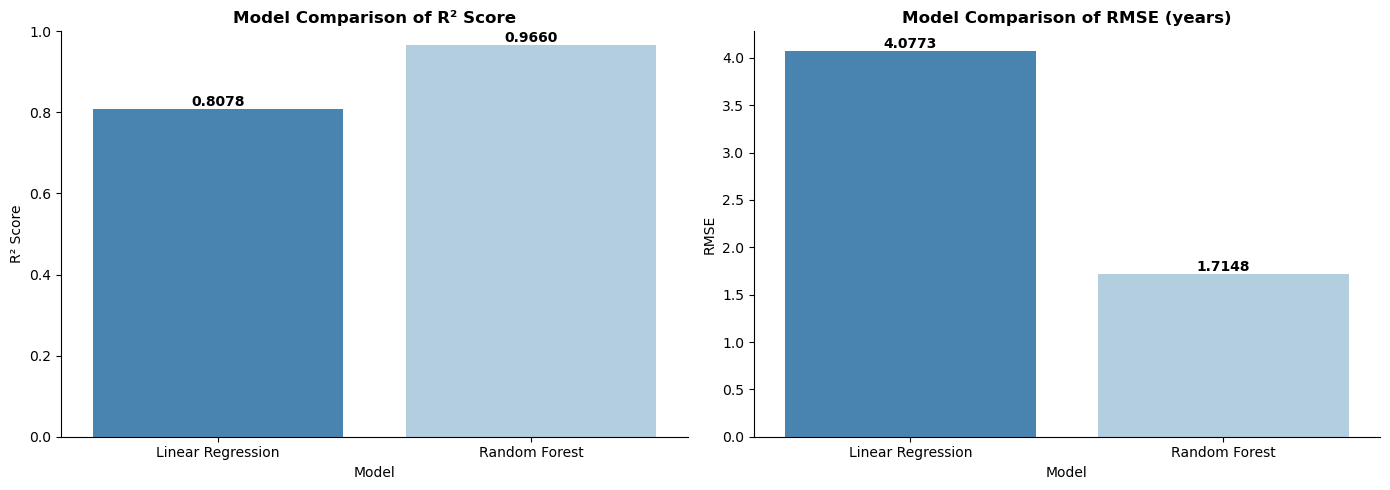

In [19]:
# ──Model Comparison ──────────────────────────────────────────────────
comparison = pd.DataFrame({
    "Model"   : ["Linear Regression", "Random Forest"],
    "R² Score": [lr_r2, rf_r2],
    "RMSE"    : [lr_rmse, rf_rmse]
})

print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² comparison
sns.barplot(data=comparison, x="Model", y="R² Score", 
            palette="Blues_r", ax=axes[0])
axes[0].set_title("Model Comparison of R² Score", fontweight="bold")
axes[0].set_ylim(0, 1)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.4f}",
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontweight="bold")

# RMSE comparison
sns.barplot(data=comparison, x="Model", y="RMSE",
            palette="Blues_r", ax=axes[1])
axes[1].set_title("Model Comparison of RMSE (years)", fontweight="bold")
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.4f}",
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.savefig(OUTPUTS / "model_comparison.png", dpi=150)
plt.show()

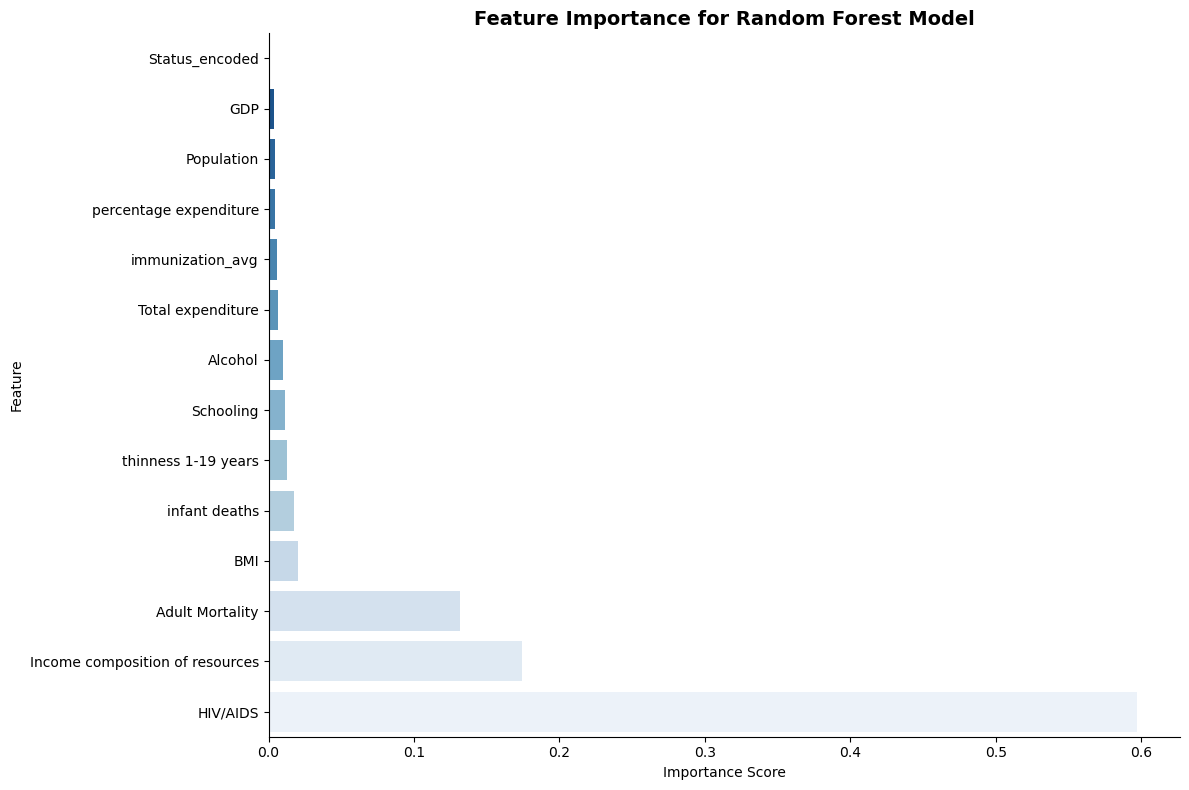

In [20]:
# ──Feature Importance (Random Forest) ────────────────────────────────
importance_df = pd.DataFrame({
    "Feature"   : features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, x="Importance", y="Feature", palette="Blues_r")
plt.title("Feature Importance for Random Forest Model",
          fontsize=14, fontweight="bold")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(OUTPUTS / "feature_importance.png", dpi=150)
plt.show()

#### **Model Results & Feature Importance Observations**

| Model | R² Score | RMSE |
|-------|----------|------|
| Linear Regression | 0.8078 | 4.08 years |
| Random Forest | 0.9660 | 1.71 years |

- **Random Forest significantly outperforms Linear Regression** . R² improves from 0.81 to 0.97 and RMSE drops from 4.08 to 1.71 years, reflecting Random Forest's ability to capture non-linear relationships and feature interactions
- **Linear Regression** still performs respectably at 0.81 R² confirming that many relationships in this dataset have a meaningful linear component
- **HIV/AIDS is the most important feature (0.60)** in the Random Forest model despite ranking second in correlation analysis. This reflects its non-linear impact: most countries have low rates but Sub-Saharan African countries with very high HIV/AIDS rates experience dramatic life expectancy drops that Random Forest captures through decision tree splits
- **Income composition of resources (0.17)** ranks second, confirming that efficient conversion of national income into human development is a critical life expectancy driver
- **Adult Mortality (0.13)** ranks third with direct mortality pressure as expected
- **Schooling**, despite being the top correlator, has relatively low feature importance in Random Forest likely because its effect is partially captured through Income composition of resources which is highly correlated with it
- **GDP, Status and Population have near-zero importance** suggesting that raw economic size matters less than how resources are distributed and utilised

---
## **Summary & Conclusions**

In [21]:
# ──Summary Statistics ───────────────────────────────────────────────
summary = pd.read_sql("""
    SELECT
        COUNT(DISTINCT Country) as Total_Countries,
        COUNT(DISTINCT Year) as Years_Covered,
        ROUND(AVG("Life expectancy"), 1) as Global_Avg_Life_Expectancy,
        ROUND(MIN("Life expectancy"), 1) as Min_Life_Expectancy,
        ROUND(MAX("Life expectancy"), 1) as Max_Life_Expectancy,
        ROUND(AVG(CASE WHEN Status='Developed' 
                  THEN "Life expectancy" END), 1) as Developed_Avg,
        ROUND(AVG(CASE WHEN Status='Developing' 
                  THEN "Life expectancy" END), 1) as Developing_Avg,
        ROUND(AVG(Schooling), 1) as Avg_Schooling_Years,
        ROUND(AVG("Adult Mortality"), 1) as Avg_Adult_Mortality
    FROM life_expectancy_clean
""", conn)

summary.T.rename(columns={0: "Value"})

,Value
Total_Countries,183.00
Years_Covered,16.00
Global_Avg_Life_Expectancy,69.20
Min_Life_Expectancy,36.30
Max_Life_Expectancy,89.00
Developed_Avg,79.20
Developing_Avg,67.10
Avg_Schooling_Years,12.00
Avg_Adult_Mortality,164.80


#### **Key Metrics**

| Metric | Value |
|--------|-------|
| Total Countries | 183 |
| Years Covered | 2000-2015 |
| Global Average Life Expectancy | 69.2 years |
| Minimum Life Expectancy | 36.3 years |
| Maximum Life Expectancy | 89.0 years |
| Developed Countries Average | 79.2 years |
| Developing Countries Average | 67.1 years |
| Development Gap | 12.1 years |
| Average Schooling Years | 12.0 years |
| Average Adult Mortality | 164.8 per 1,000 |

#### **Answers to Key Project Questions**

1. **Which factors most significantly affect life expectancy?**
HIV/AIDS, Income composition of resources and Adult Mortality are the strongest predictors per Random Forest feature importance. Schooling and BMI show the strongest linear correlations.

2. **Should countries with low life expectancy increase healthcare expenditure?**
Healthcare expenditure alone has low predictive power. The data suggests investing in education, income distribution and HIV/AIDS control yields greater life expectancy improvements than raw spending increases.

3. **How do infant and adult mortality affect life expectancy?**
Adult Mortality has a strong negative correlation (-0.70) and is the third most important ML feature. Infant mortality compounds this effect. Both directly compress life expectancy and signal broader healthcare system failures.

4. **What is the impact of schooling on lifespan?**
Schooling is the strongest linear predictor (0.72 correlation) as more years of education directly improves health literacy, disease prevention and healthcare seeking behaviour.

5. **Can we reliably predict life expectancy from these factors?**
Yes. The Random Forest model achieves R²=0.966 and RMSE=1.71 years, meaning predictions are accurate to within less than 2 years using 14 health, economic and social indicators.

#### **Model Summary**

| Model | R² Score | RMSE | Verdict |
|-------|----------|------|---------|
| Linear Regression | 0.8078 | 4.08 years | Good baseline |
| Random Forest | 0.9660 | 1.71 years | Strong and recommended |

#### **Limitations**
- Data spans 2000-2015 and does not reflect post-2015 developments including COVID-19 pandemic impact on global life expectancy
- Missing data was concentrated in smaller/less developed nations. Imputation may introduce bias for those countries
- Feature importance from Random Forest can be influenced by correlated features so results should be interpreted alongside domain knowledge
- The 36.3 year minimum life expectancy reflects extreme conflict or epidemic situations that may be outliers rather than representative of sustained trends